In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib.font_manager as font_manager

In [2]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['svg.fonttype'] = 'none'

## load layouts from file

In [3]:
Experiment1Layout = pd.read_csv("250324_mACmChPOLR2A_90min_IF/METADATA/250324_mACmChPOLR2A_90minIF.csv")
Experiment2Layout = pd.read_csv("250510_mACmChPOLR2A_90min_IF/METADATA/250510_mACmChPOLR2A_90min_IF.csv")
Experiment3Layout = pd.read_csv("250523_mACmChPOLR2A_90min_IF/METADATA/250523_mACmChPOLR2A_90minIF.csv")

## for each experiment, load quantification files from relevant directories, and assemble into data frames

In [5]:
Experiment1_Quantification_Directory = Path("/Users/alexandergillis/Desktop/KATANA_PULL/250324_mACmChPOLR2A_90min_IF/20250330_155613_960/QUANTIFICATION/")
Experiment1_Quantification_Files = glob.glob(str(Experiment1_Quantification_Directory / "*.csv"))

Experiment2_Quantification_Directory = Path("/Users/alexandergillis/Desktop/KATANA_PULL/250510_mACmChPOLR2A_90min_IF/20250514_223845_949/QUANTIFICATION")
Experiment2_Quantification_Files = glob.glob(str(Experiment2_Quantification_Directory / "*.csv"))

Experiment3_Quantification_Directory = Path("/Users/alexandergillis/Desktop/KATANA_PULL/250523_mACmChPOLR2A_90min_IF/20250526_171602_963/QUANTIFICATION")
Experiment3_Quantification_Files = glob.glob(str(Experiment3_Quantification_Directory / "*.csv"))

len(Experiment1_Quantification_Files), len(Experiment2_Quantification_Files), len(Experiment3_Quantification_Files)

(600, 600, 600)

In [6]:
qdfs = list()


for f in tqdm(Experiment1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment1_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment1_PerCell['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment1_PerCell['fov'] = fovs

Experiment1_Intensities = pd.DataFrame({
    "WELL" : Experiment1_PerCell['well'],
    "IF_647_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_647'],
    "RFP_561_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_561'],
    "GFP_488_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment1_PerCell['Nuclei_area']
})

100%|████████████████████████████████████████| 600/600 [00:04<00:00, 124.73it/s]


In [7]:
qdfs = list()


for f in tqdm(Experiment2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment2_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment2_PerCell['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment2_PerCell['fov'] = fovs

Experiment2_Intensities = pd.DataFrame({
    "WELL" : Experiment2_PerCell['well'],
    "IF_647_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_647'],
    "RFP_561_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_561'],
    "GFP_488_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment2_PerCell['Nuclei_area']
})

100%|█████████████████████████████████████████| 600/600 [00:07<00:00, 76.24it/s]


In [8]:
qdfs = list()


for f in tqdm(Experiment3_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment3_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment3_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment3_PerCell['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment3_PerCell['fov'] = fovs

Experiment3_Intensities = pd.DataFrame({
    "WELL" : Experiment3_PerCell['well'],
    "IF_647_Intensity" : Experiment3_PerCell['Nuclei_intensity_mean_647'],
    "RFP_561_Intensity" : Experiment3_PerCell['Nuclei_intensity_mean_561'],
    "GFP_488_Intensity" : Experiment3_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment3_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment3_PerCell['Nuclei_area']
})

100%|█████████████████████████████████████████| 600/600 [00:08<00:00, 71.08it/s]


In [9]:
CountsByWell1 = Experiment1_Intensities.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell1.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment1 = Experiment1_Intensities.groupby('WELL').mean().reset_index().merge(Experiment1Layout, how = 'left')
IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.merge(CountsByWell1, how = 'left')
IntensitiesByWell_Experiment1['EXPERIMENT'] = '250324_mACmChPOLR2A_90min_IF'

CountsByWell2 = Experiment2_Intensities.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment2 = Experiment2_Intensities.groupby('WELL').mean().reset_index().merge(Experiment2Layout, how = 'left')
IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.merge(CountsByWell2, how = 'left')
IntensitiesByWell_Experiment2['EXPERIMENT'] = '250510_mACmChPOLR2A_90min_IF'

CountsByWell3 = Experiment3_Intensities.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell3.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment3 = Experiment3_Intensities.groupby('WELL').mean().reset_index().merge(Experiment3Layout, how = 'left')
IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3.merge(CountsByWell3, how = 'left')
IntensitiesByWell_Experiment3['EXPERIMENT'] = '250523_mACmChPOLR2A_90min_IF'

## save well means as csv

In [12]:
IntensitiesByWell_Experiment1.to_csv('250324_mACmChPOLR2A_90min_IF/250324_mACmChPOLR2A_90min_IF_well_means.csv')
IntensitiesByWell_Experiment2.to_csv('250510_mACmChPOLR2A_90min_IF/250510_mACmChPOLR2A_90min_IF_well_means.csv')
IntensitiesByWell_Experiment3.to_csv('250523_mACmChPOLR2A_90min_IF/250523_mACmChPOLR2A_90min_IF_well_means.csv')

## examine raw data per experiment

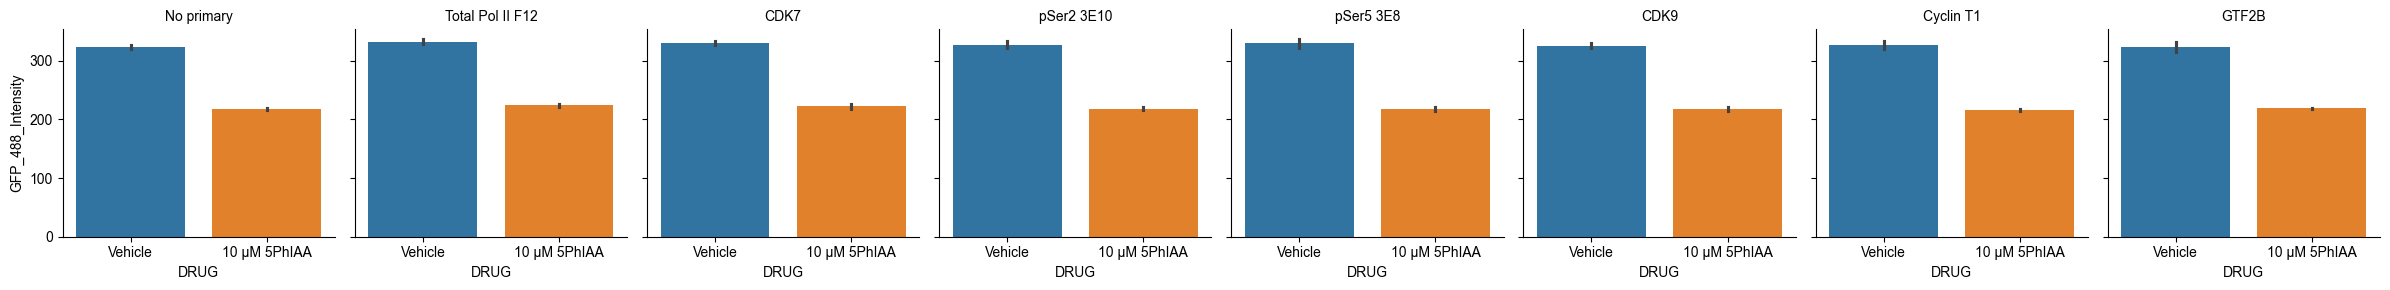

In [13]:
g = sns.FacetGrid(IntensitiesByWell_Experiment1,
                  col = 'PRIMARY',
                  row = 'EXPERIMENT',
                 aspect = 1)

g.map_dataframe(sns.barplot,
                x = 'DRUG', order = ['Vehicle', '10 µM 5PhIAA'],
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'], dodge = False, palette = 'tab10',
                errorbar = 'sd',
                y = 'GFP_488_Intensity')

g.set_titles(template="{col_name}")

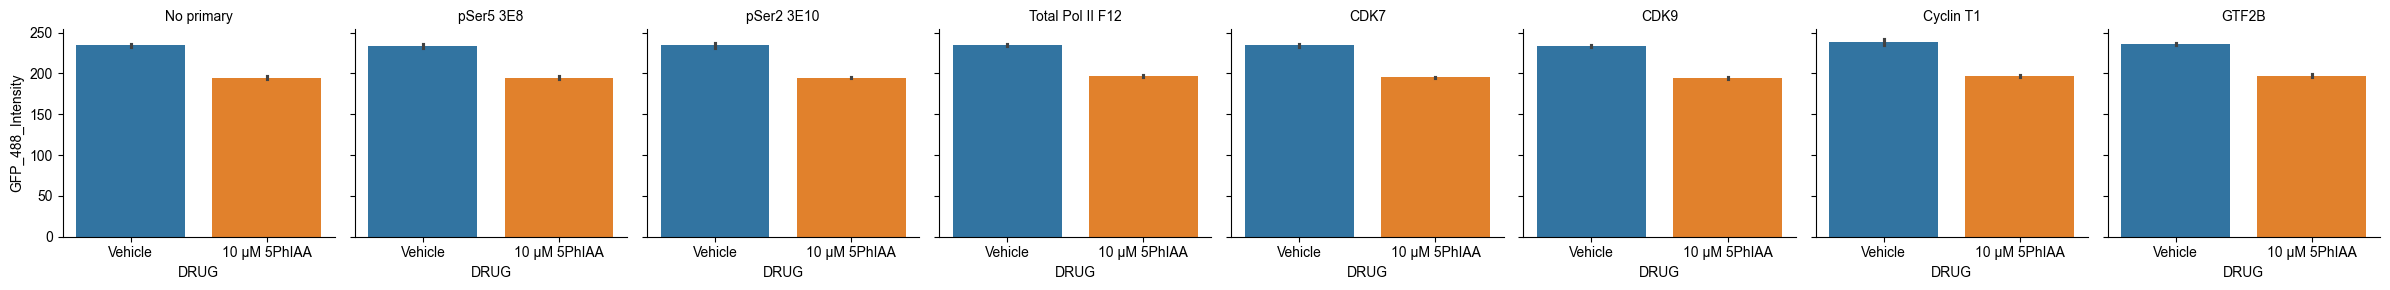

In [14]:
g = sns.FacetGrid(IntensitiesByWell_Experiment2,
                  col = 'PRIMARY',
                  row = 'EXPERIMENT',
                 aspect = 1)

g.map_dataframe(sns.barplot,
                x = 'DRUG', order = ['Vehicle', '10 µM 5PhIAA'],
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'], dodge = False, palette = 'tab10',
                errorbar = 'sd',
                y = 'GFP_488_Intensity')

g.set_titles(template="{col_name}")

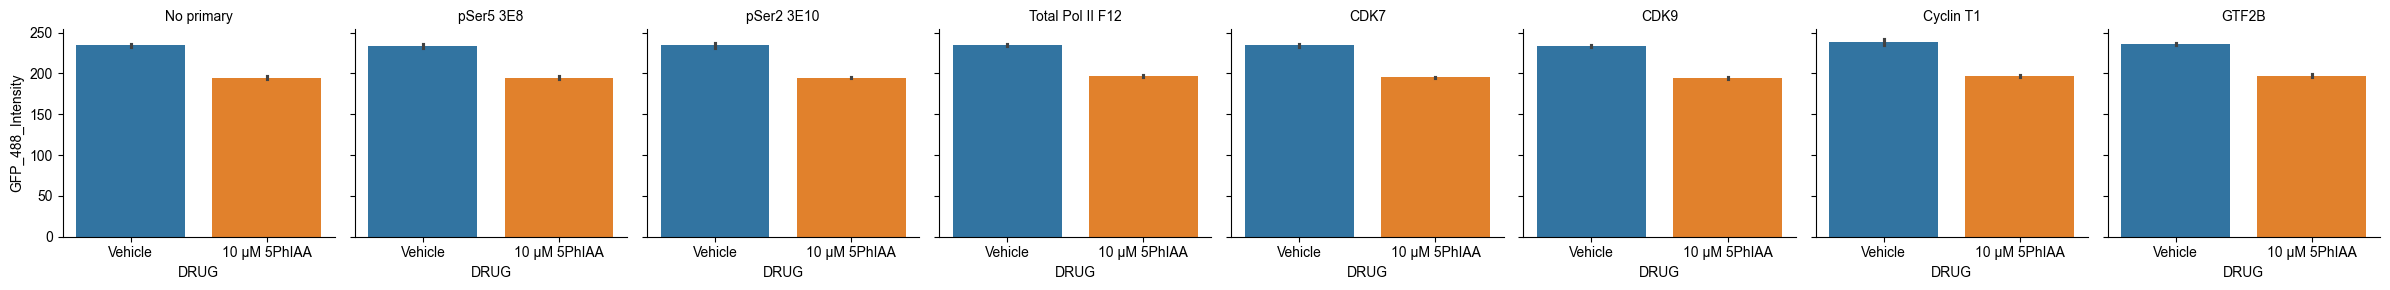

In [15]:
g = sns.FacetGrid(IntensitiesByWell_Experiment2,
                  col = 'PRIMARY',
                  row = 'EXPERIMENT',
                 aspect = 1)

g.map_dataframe(sns.barplot,
                x = 'DRUG', order = ['Vehicle', '10 µM 5PhIAA'],
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'], dodge = False, palette = 'tab10',
                errorbar = 'sd',
                y = 'GFP_488_Intensity')

g.set_titles(template="{col_name}")

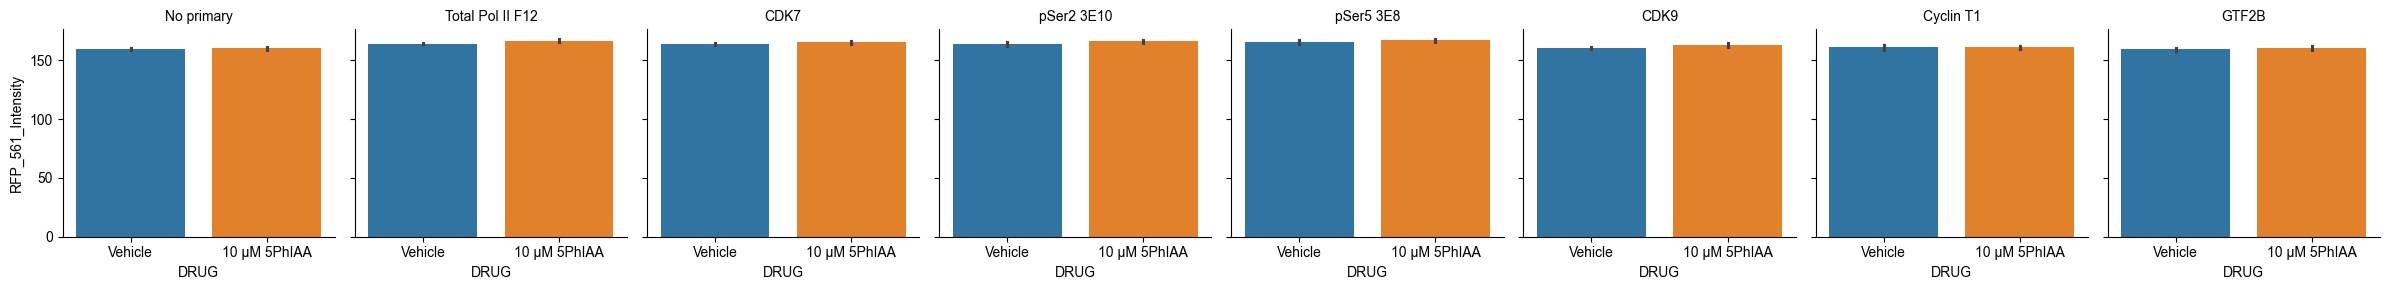

In [16]:
g = sns.FacetGrid(IntensitiesByWell_Experiment1,
                  col = 'PRIMARY',
                  row = 'EXPERIMENT',
                 aspect = 1)

g.map_dataframe(sns.barplot,
                x = 'DRUG', order = ['Vehicle', '10 µM 5PhIAA'],
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'], dodge = False, palette = 'tab10',
                errorbar = 'sd',
                y = 'RFP_561_Intensity')

g.set_titles(template="{col_name}")

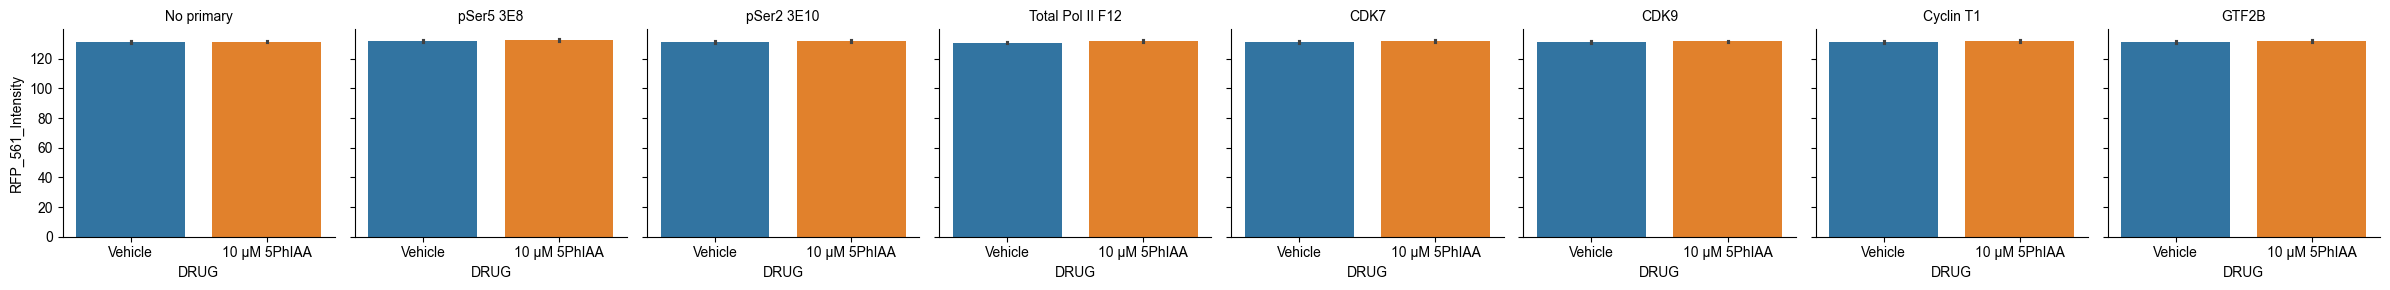

In [17]:
g = sns.FacetGrid(IntensitiesByWell_Experiment2,
                  col = 'PRIMARY',
                  row = 'EXPERIMENT',
                 aspect = 1)

g.map_dataframe(sns.barplot,
                x = 'DRUG', order = ['Vehicle', '10 µM 5PhIAA'],
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'], dodge = False, palette = 'tab10',
                errorbar = 'sd',
                y = 'RFP_561_Intensity')

g.set_titles(template="{col_name}")

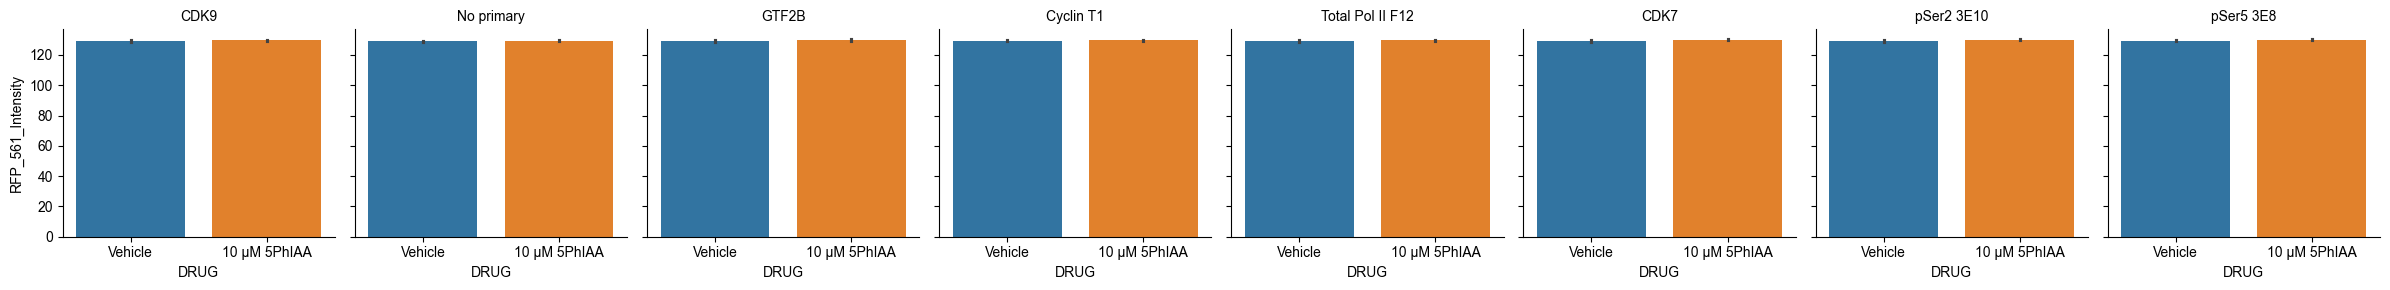

In [18]:
g = sns.FacetGrid(IntensitiesByWell_Experiment3,
                  col = 'PRIMARY',
                  row = 'EXPERIMENT',
                 aspect = 1)

g.map_dataframe(sns.barplot,
                x = 'DRUG', order = ['Vehicle', '10 µM 5PhIAA'],
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'], dodge = False, palette = 'tab10',
                errorbar = 'sd',
                y = 'RFP_561_Intensity')

g.set_titles(template="{col_name}")

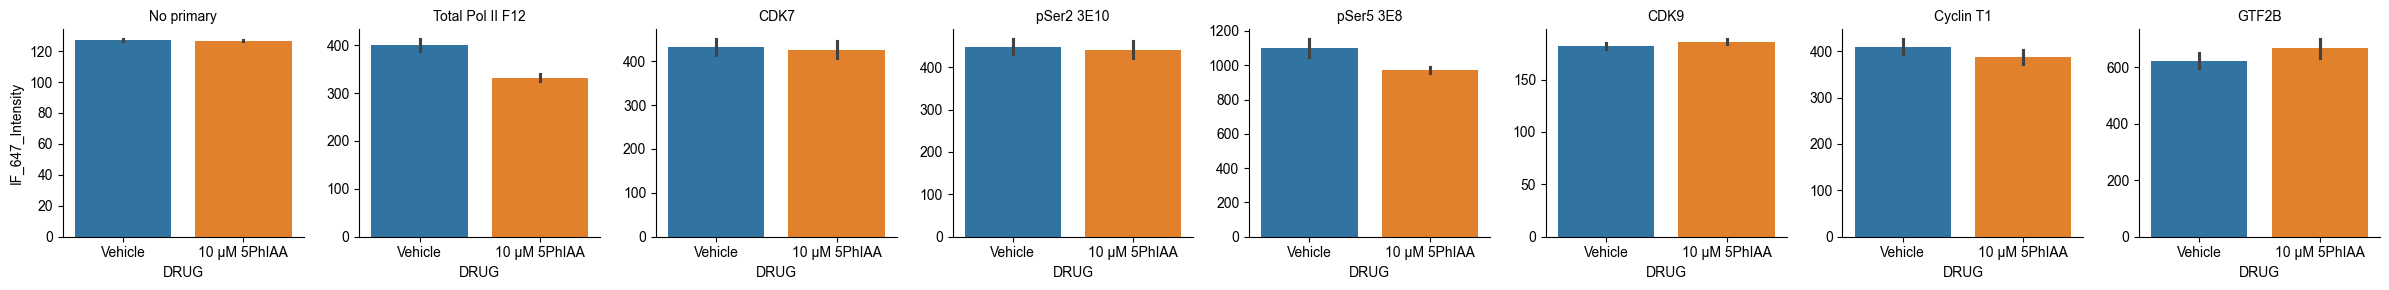

In [19]:
g = sns.FacetGrid(IntensitiesByWell_Experiment1,
                  col = 'PRIMARY',
                  row = 'EXPERIMENT',
                 aspect = 1,
                  sharey = False)

g.map_dataframe(sns.barplot,
                x = 'DRUG', order = ['Vehicle', '10 µM 5PhIAA'],
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'], dodge = False, palette = 'tab10',
                errorbar = 'sd',
                y = 'IF_647_Intensity')

g.set_titles(template="{col_name}")

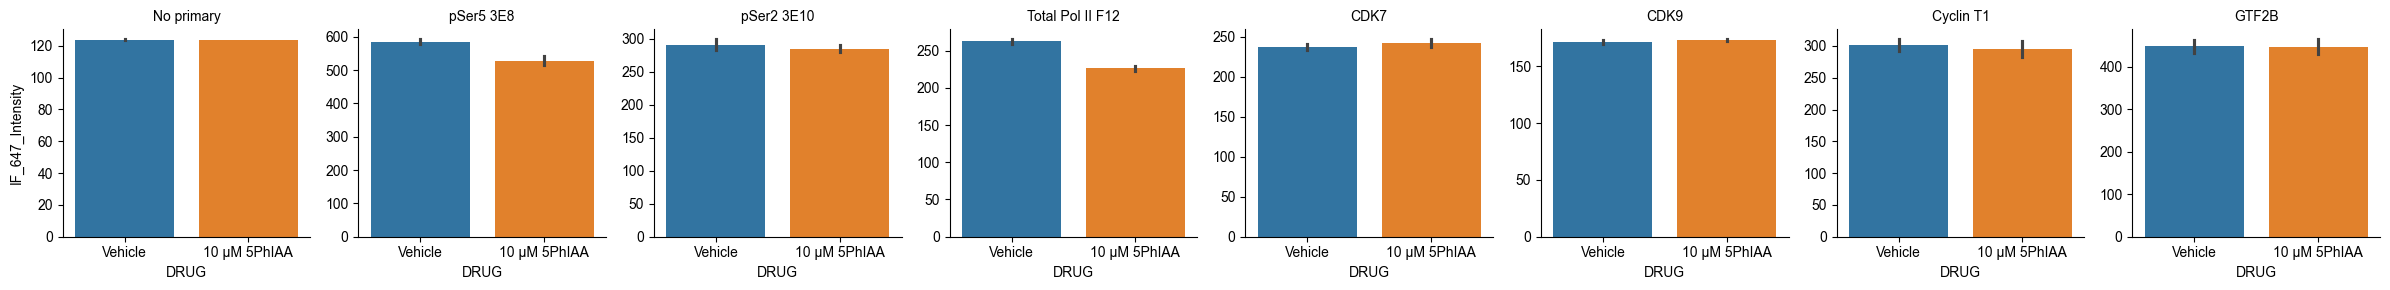

In [20]:
g = sns.FacetGrid(IntensitiesByWell_Experiment2,
                  col = 'PRIMARY',
                  row = 'EXPERIMENT',
                 aspect = 1,
                  sharey = False)

g.map_dataframe(sns.barplot,
                x = 'DRUG', order = ['Vehicle', '10 µM 5PhIAA'],
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'], dodge = False, palette = 'tab10',
                errorbar = 'sd',
                y = 'IF_647_Intensity')

g.set_titles(template="{col_name}")

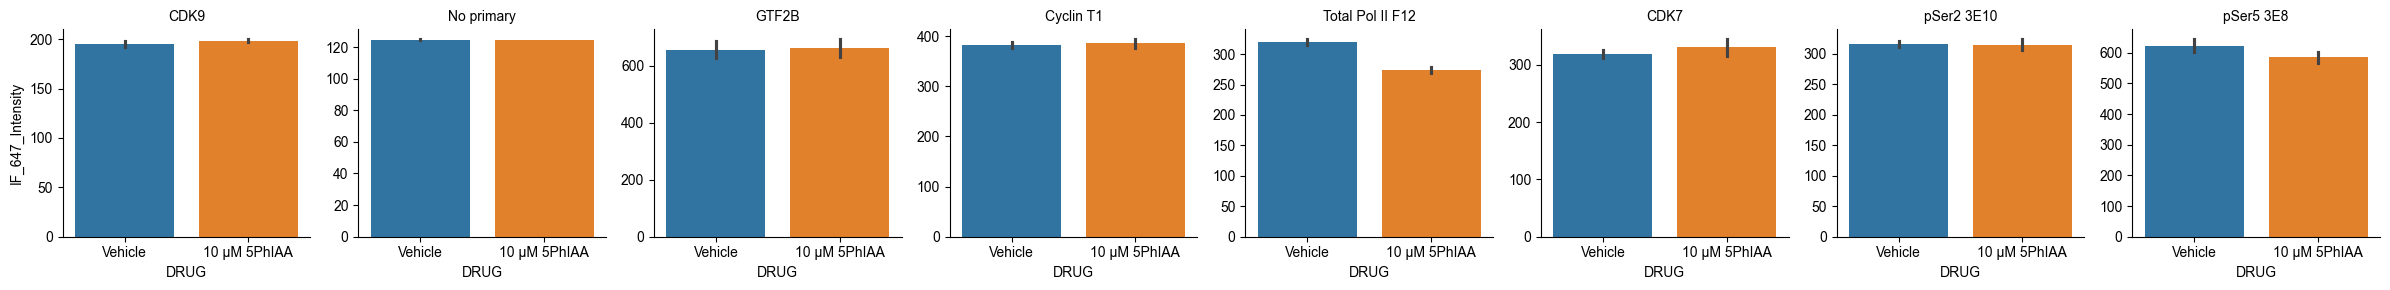

In [21]:
g = sns.FacetGrid(IntensitiesByWell_Experiment3,
                  col = 'PRIMARY',
                  row = 'EXPERIMENT',
                 aspect = 1,
                  sharey = False)

g.map_dataframe(sns.barplot,
                x = 'DRUG', order = ['Vehicle', '10 µM 5PhIAA'],
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'], dodge = False, palette = 'tab10',
                errorbar = 'sd',
                y = 'IF_647_Intensity')

g.set_titles(template="{col_name}")

## normalise intensities for each primary within experiments

In [22]:
ZeroVal_E1 = IntensitiesByWell_Experiment1.query('PRIMARY == "No primary" & SECONDARY != "DAPI only"')['IF_647_Intensity'].mean()
ZeroVal_E2 = IntensitiesByWell_Experiment2.query('PRIMARY == "No primary" & SECONDARY != "DAPI only"')['IF_647_Intensity'].mean()
ZeroVal_E3 = IntensitiesByWell_Experiment3.query('PRIMARY == "No primary" & SECONDARY != "DAPI only"')['IF_647_Intensity'].mean()

In [23]:
IntensitiesByWell_Experiment1['IF_647_Intensity_BGS'] = IntensitiesByWell_Experiment1['IF_647_Intensity'] - ZeroVal_E1
IntensitiesByWell_Experiment2['IF_647_Intensity_BGS'] = IntensitiesByWell_Experiment2['IF_647_Intensity'] - ZeroVal_E2
IntensitiesByWell_Experiment3['IF_647_Intensity_BGS'] = IntensitiesByWell_Experiment3['IF_647_Intensity'] - ZeroVal_E3

In [24]:
frames = []

for p in IntensitiesByWell_Experiment1.query('PRIMARY != "No primary"').PRIMARY.unique():
    
    p_frame = IntensitiesByWell_Experiment1[IntensitiesByWell_Experiment1['PRIMARY'] == p]
    
    Hundred_Val = p_frame.query('DRUG == "Vehicle"').IF_647_Intensity_BGS.mean()

    p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)

    frames.append(p_frame)

NormalisedIntensitiesByWell_Experiment1 = pd.concat(frames)

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_523/1224690711.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_523/1224690711.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_523/1224690711.py:9: SettingWithCopyWar

In [25]:
frames = []

for p in IntensitiesByWell_Experiment2.query('PRIMARY != "No primary"').PRIMARY.unique():
    
    p_frame = IntensitiesByWell_Experiment2[IntensitiesByWell_Experiment2['PRIMARY'] == p]
    
    Hundred_Val = p_frame.query('DRUG == "Vehicle"').IF_647_Intensity_BGS.mean()

    p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)

    frames.append(p_frame)

NormalisedIntensitiesByWell_Experiment2 = pd.concat(frames)

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_523/664613065.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_523/664613065.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_523/664613065.py:9: SettingWithCopyWarnin

In [26]:
frames = []

for p in IntensitiesByWell_Experiment3.query('PRIMARY != "No primary"').PRIMARY.unique():
    
    p_frame = IntensitiesByWell_Experiment3[ (IntensitiesByWell_Experiment3['PRIMARY'] == p) & (IntensitiesByWell_Experiment3['SECONDARY'] != "DAPI only")]
    
    Hundred_Val = p_frame.query('DRUG == "Vehicle"').IF_647_Intensity_BGS.mean()

    p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)

    frames.append(p_frame)

NormalisedIntensitiesByWell_Experiment3 = pd.concat(frames)

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_523/245056203.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_523/245056203.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_523/245056203.py:9: SettingWithCopyWarnin

In [27]:
NormalisedIntensitiesByWell = pd.concat([NormalisedIntensitiesByWell_Experiment1,NormalisedIntensitiesByWell_Experiment2,NormalisedIntensitiesByWell_Experiment3])
NormalisedIntensitiesByWell = NormalisedIntensitiesByWell.query('DRUG != "No addition"')

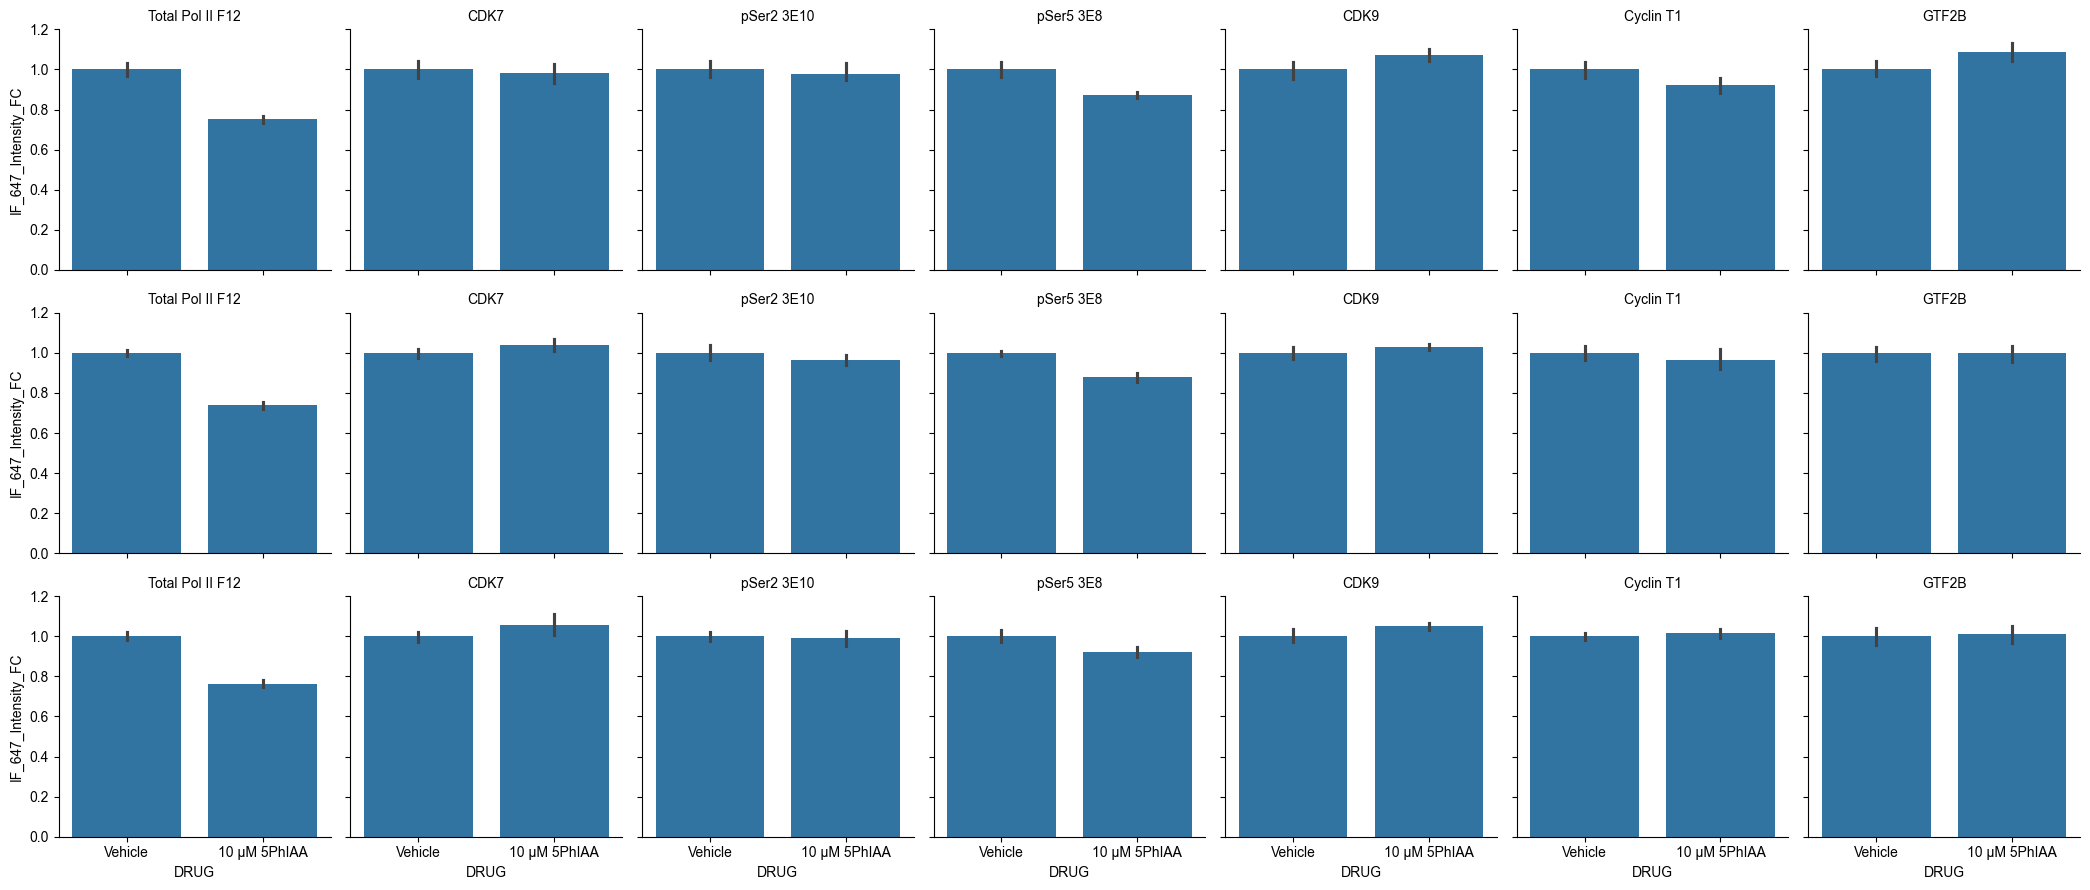

In [28]:
g = sns.FacetGrid(NormalisedIntensitiesByWell,
                  row = 'EXPERIMENT',
                  col = 'PRIMARY',
                  aspect = 1,
                 ylim = (0,1.2))

g.map_dataframe(sns.barplot,
                x = 'DRUG', order = ['Vehicle', '10 µM 5PhIAA'],
                y = 'IF_647_Intensity_FC')

g.set_titles(template="{col_name}")

# plots for manuscript

In [29]:
NormalisedIntensitiesByWell.PRIMARY.unique()

array(['Total Pol II F12', 'CDK7', 'pSer2 3E10', 'pSer5 3E8', 'CDK9',
       'Cyclin T1', 'GTF2B'], dtype=object)

In [30]:
NormalisedIntensitiesByWell.to_csv('mACmChPOLR2A_90min_IF_ByExperiment.csv')

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_523/1401340438.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a[0].set_xticklabels(['Total\n(F12)','pSer5\n(3E8)','pSer2\n(3E10)'], fontsize = 8)


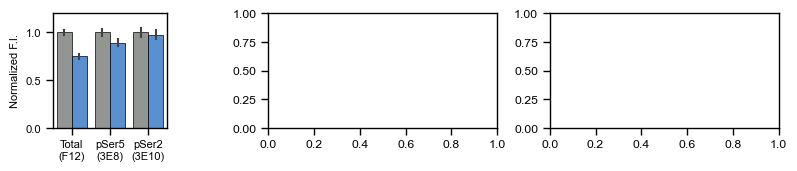

In [40]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (8,1.6), layout = 'constrained')

cp = sns.color_palette(['xkcd:grey','xkcd:dark sky blue'])

selected_f12_3e8_3e10 = ["Total Pol II F12", "pSer5 3E8", "pSer2 3E10"]

g = sns.barplot(NormalisedIntensitiesByWell.query('PRIMARY in @selected_f12_3e8_3e10'),
            x = 'PRIMARY', order = selected_f12_3e8_3e10,
            y = 'IF_647_Intensity_FC',
            hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                edgecolor = 'black', linewidth = 0.5,
            dodge = True,
            errorbar = 'sd', errwidth = 1.5,
            palette = cp,
                ax = a[0])

g.get_legend().remove()

a[0].set_xlabel('')

m = a[0].get_xticks()

a[0].set_xticklabels(['Total\n(F12)','pSer5\n(3E8)','pSer2\n(3E10)'], fontsize = 8)

a[0].set_ylim(0,1.2)
a[0].set_yticks([0, 0.5, 1])

a[0].set_box_aspect(1)

a[0].set_ylabel('Normalized F.I.', fontsize = 8);
a[0].tick_params(axis = 'y', labelsize = 8)

plt.savefig('mACmChPOLR2A_90min_Total_pSer2_pSer5.svg')

In [45]:
NormalisedIntensitiesByWell[['DRUG','PRIMARY','WELL']].groupby(['DRUG','PRIMARY']).count().reset_index()

,DRUG,PRIMARY,WELL
0,10 µM 5PhIAA,CDK7,18
1,10 µM 5PhIAA,CDK9,18
2,10 µM 5PhIAA,Cyclin T1,18
3,10 µM 5PhIAA,GTF2B,18
4,10 µM 5PhIAA,Total Pol II F12,18
5,10 µM 5PhIAA,pSer2 3E10,18
6,10 µM 5PhIAA,pSer5 3E8,18
7,Vehicle,CDK7,18
8,Vehicle,CDK9,18
9,Vehicle,Cyclin T1,18


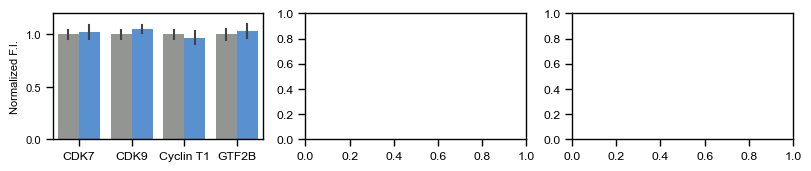

In [41]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (8,1.6), layout = 'constrained')

cp = sns.color_palette(['xkcd:grey','xkcd:dark sky blue'])

selected_f12_3e8_3e10 = ["Total Pol II F12", "pSer5 3E8", "pSer2 3E10"]

g = sns.barplot(NormalisedIntensitiesByWell.query('PRIMARY not in @selected_f12_3e8_3e10'),
            x = 'PRIMARY',
            y = 'IF_647_Intensity_FC',
            hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
            dodge = True,
            errorbar = 'sd', errwidth = 1.5,
            palette = cp,
                ax = a[0])

g.get_legend().remove()

a[0].set_xlabel('')

m = a[0].get_xticks()

a[0].set_ylim(0,1.2)
a[0].set_yticks([0, 0.5, 1])

a[0].set_box_aspect(0.6)

a[0].set_ylabel('Normalized F.I.', fontsize = 8);
a[0].tick_params(axis = 'y', labelsize = 8)

plt.savefig('mACmChPOLR2A_90min_CDK7_CDK9_CCNT1_GTF2B.svg')